In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('athlete_events.csv', low_memory=False)

# Filter only medal-winning entries
medals_df = df[df['Medal'].notna()]

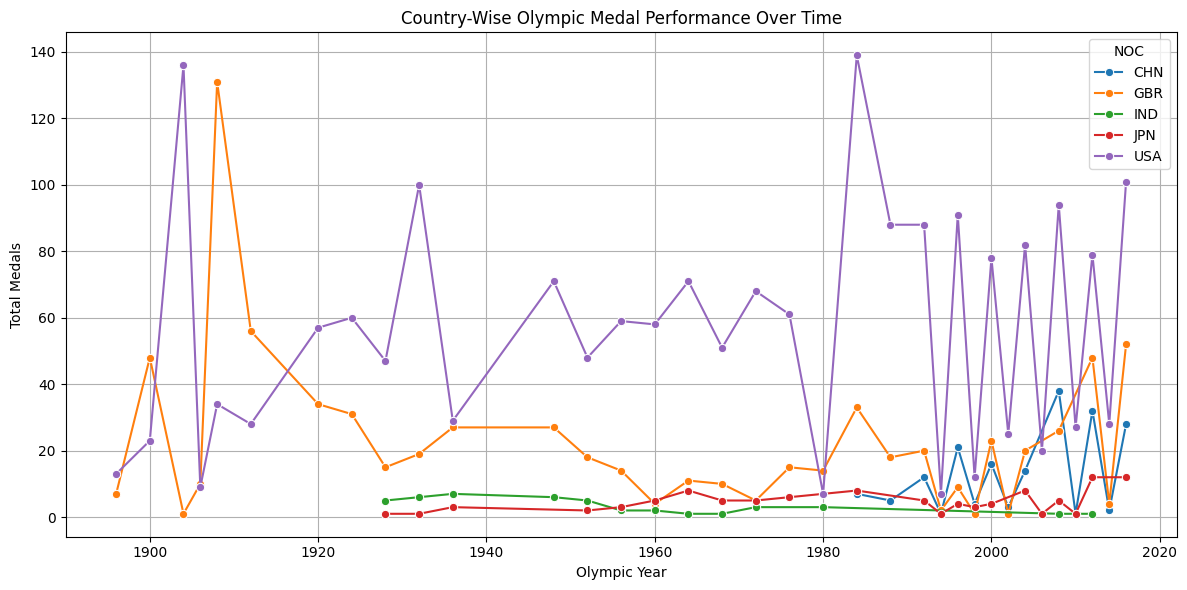

In [ ]:
# Group by country and year
country_year_medals = medals_df.groupby(['NOC', 'Year'])['Medal'].count().reset_index()
country_year_medals.rename(columns={'Medal': 'Total_Medals'}, inplace=True)

# Select countries to compare
selected_countries = ['USA', 'CHN', 'IND', 'GBR', 'JPN']
filtered = country_year_medals[country_year_medals['NOC'].isin(selected_countries)]

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=filtered, x='Year', y='Total_Medals', hue='NOC', marker='o')
plt.title('Country-Wise Olympic Medal Performance Over Time')
plt.xlabel('Olympic Year')
plt.ylabel('Total Medals')
plt.grid(True)
plt.tight_layout()
plt.show()

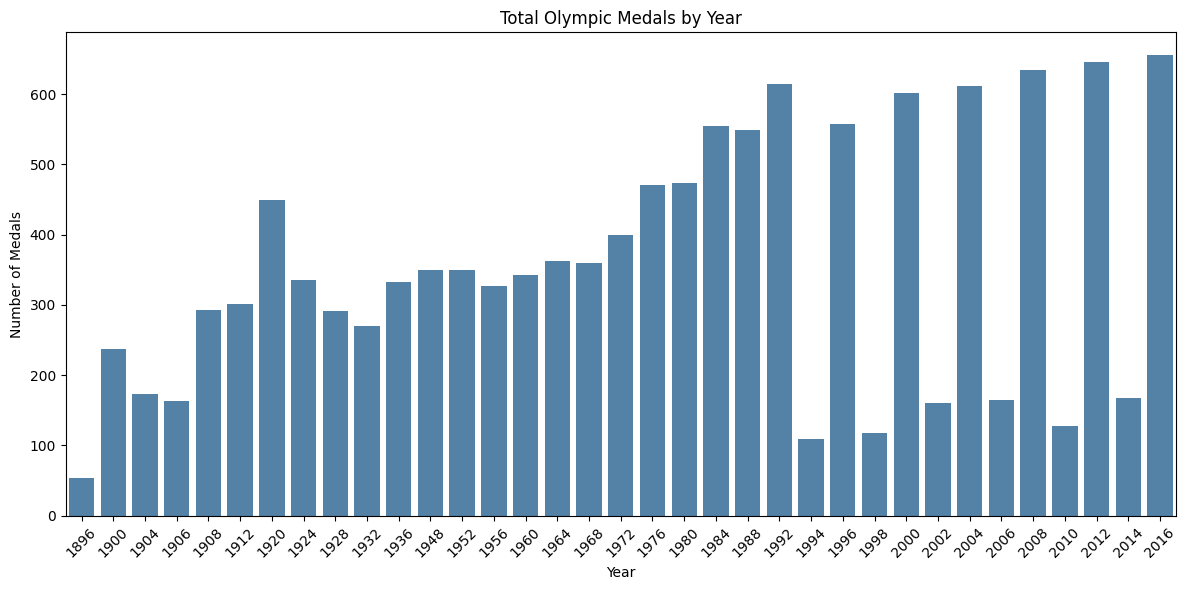

In [ ]:
# Total medals per year
yearly_medals = medals_df.groupby('Year')['Medal'].count().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=yearly_medals, x='Year', y='Medal', color='steelblue')
plt.title('Total Olympic Medals by Year')
plt.xticks(rotation=45)
plt.ylabel('Number of Medals')
plt.tight_layout()
plt.show()

/tmp/ipython-input-3891211797.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Medals_Per_Capita', y='NOC', data=top_per_capita, palette='viridis')


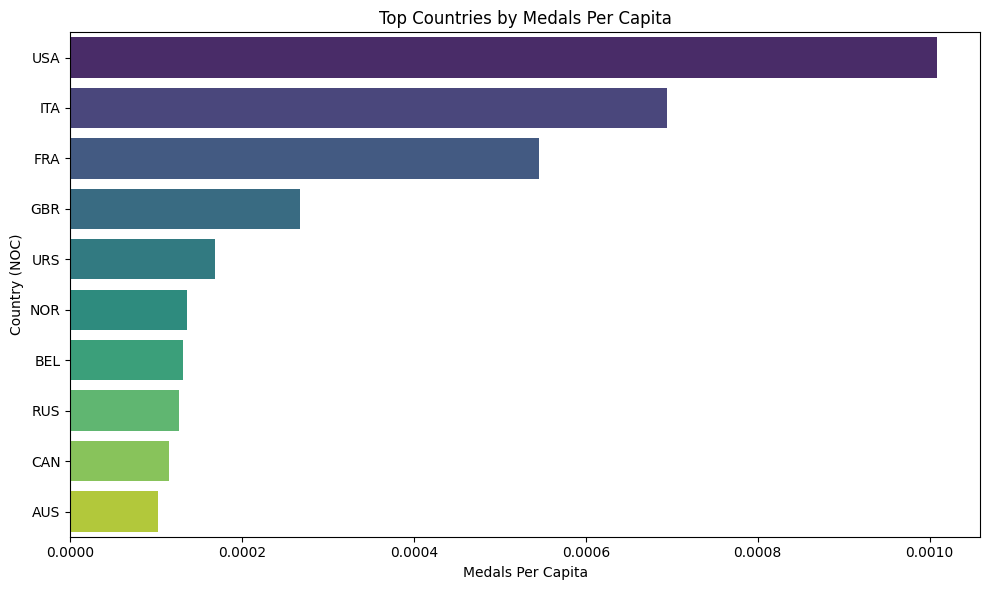

In [ ]:
# Total medals per country
country_medals = medals_df.groupby('NOC')['Medal'].count().reset_index(name='Total_Medals')

# Load population data
pop_df = pd.read_csv('noc_regions.csv')  # Columns: NOC, Population

# Merge and calculate medals per capita
merged = pd.merge(country_medals, pop_df, on='NOC', how='left')
merged = merged[merged['population'].notna() & (merged['population'] > 0)]
merged['Medals_Per_Capita'] = merged['Total_Medals'] / merged['population']

# Top countries by medals per capita
top_per_capita = merged.sort_values(by='Medals_Per_Capita', ascending=False).head(10)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x='Medals_Per_Capita', y='NOC', data=top_per_capita, palette='viridis')
plt.title('Top Countries by Medals Per Capita')
plt.xlabel('Medals Per Capita')
plt.ylabel('Country (NOC)')
plt.tight_layout()
plt.show()

/tmp/ipython-input-2035385608.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_sports, x='Medal', y='Sport', palette='magma')


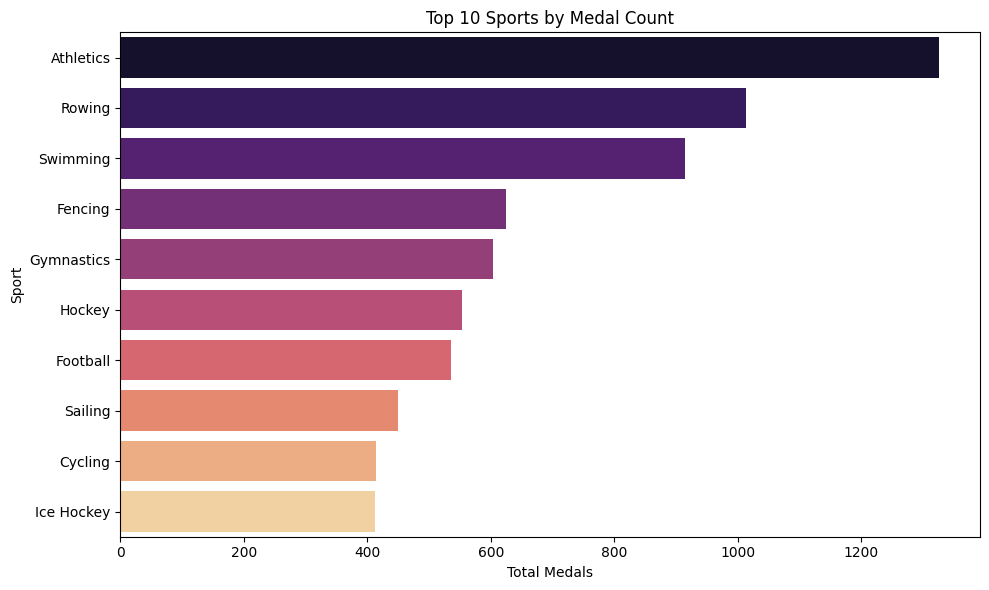

In [ ]:
# Total medals by sport
sport_medals = medals_df.groupby('Sport')['Medal'].count().reset_index()
top_sports = sport_medals.sort_values(by='Medal', ascending=False).head(10)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=top_sports, x='Medal', y='Sport', palette='magma')
plt.title('Top 10 Sports by Medal Count')
plt.xlabel('Total Medals')
plt.tight_layout()
plt.show()